Credits: https://github.com/Holmes-Alan/ImageNet_sample/tree/main

In [1]:
import torch
import torchvision

In [2]:
import torch
from torchvision import models
model = models.alexnet(pretrained=True)
model.eval()

C:\Users\Hamidur\Documents\LUT_exercises\AI_ML\FAIML_E5\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Hamidur\Documents\LUT_exercises\AI_ML\FAIML_E5\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

The best prediction:

'./polar_bear.jpg': 99.87646484375% is a 'ice bear, polar bear, Ursus Maritimus, Thalarctos maritimus'

Top 5 prediction:

99.87646484375% is a 'ice bear, polar bear, Ursus Maritimus, Thalarctos maritimus'
0.10136964172124863% is a 'white wolf, Arctic wolf, Canis lupus tundrarum'
0.019349833950400352% is a 'Arctic fox, white fox, Alopex lagopus'
0.002569720847532153% is a 'Samoyed, Samoyede'
0.0001575924688950181% is a 'kuvasz'


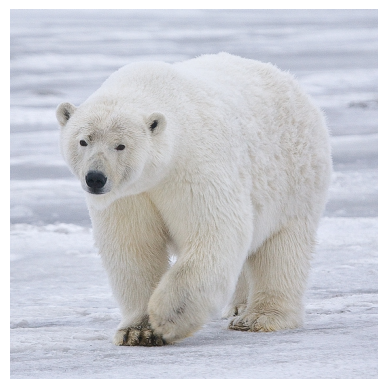

In [3]:
# sample execution (requires torchvision)
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

filename = './polar_bear.jpg'

input_image = Image.open(filename)
plt.imshow(input_image)
plt.axis('off')

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
input_tensor = preprocess(input_image)
input_batch = input_tensor.unsqueeze(0) # create a mini-batch as expected by the model

# move the input and model to GPU for speed if available
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    model.to('cuda')

with torch.no_grad():
    output = model(input_batch)

# normalize the output as probability
percentage = torch.nn.functional.softmax(output, dim=1)[0] * 100

# Load Imagenet Synsets
with open('./imagenet_synsets.txt', 'r') as f:
    synsets = f.readlines()

# len(synsets)==1001
# sysnets[0] == background
synsets = [x.strip() for x in synsets]
splits = [line.split(' ') for line in synsets]
key_to_classname = {spl[0]:' '.join(spl[1:]) for spl in splits}

with open('./imagenet_classes.txt', 'r') as f:
    class_id_to_key = f.readlines()

class_id_to_key = [x.strip() for x in class_id_to_key]

print('The best prediction:\n')
_, index = torch.max(output, 1)
classname = key_to_classname[class_id_to_key[index[0]]]
probability = percentage[index[0]].item()
print("'{}': {}% is a '{}'".format(filename, probability, classname))

print('\nTop 5 prediction:\n')
_, indices = torch.sort(output, descending=True)
for idx in indices[0][:5]:
    print("{}% is a '{}'".format(percentage[idx].item(), key_to_classname[class_id_to_key[idx]]))

Create classification reports for each image (like above)

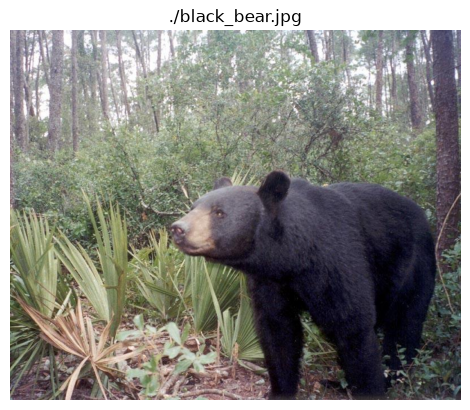

The best prediction:

'./black_bear.jpg': 87.53179931640625% is a 'American black bear, black bear, Ursus americanus, Euarctos americanus'

Top 5 prediction:

87.53179931640625% is a 'American black bear, black bear, Ursus americanus, Euarctos americanus'
5.451810836791992% is a 'brown bear, bruin, Ursus arctos'
3.2111401557922363% is a 'wild boar, boar, Sus scrofa'
2.6749753952026367% is a 'sloth bear, Melursus ursinus, Ursus ursinus'
0.1873129904270172% is a 'hog, pig, grunter, squealer, Sus scrofa'


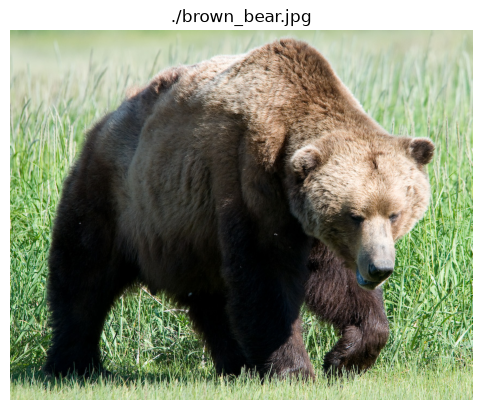

The best prediction:

'./brown_bear.jpg': 93.28685760498047% is a 'brown bear, bruin, Ursus arctos'

Top 5 prediction:

93.28685760498047% is a 'brown bear, bruin, Ursus arctos'
5.0458831787109375% is a 'bison'
1.1548504829406738% is a 'American black bear, black bear, Ursus americanus, Euarctos americanus'
0.28558996319770813% is a 'wombat'
0.08098508417606354% is a 'sloth bear, Melursus ursinus, Ursus ursinus'


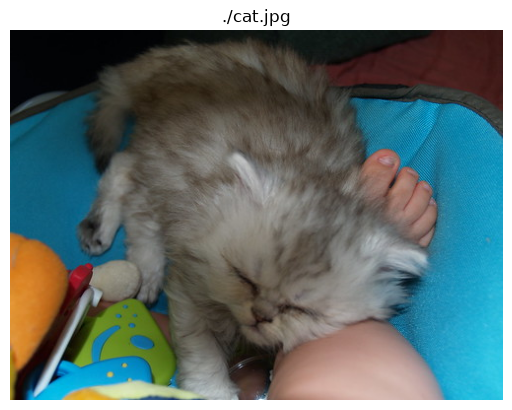

The best prediction:

'./cat.jpg': 85.8633041381836% is a 'Persian cat'

Top 5 prediction:

85.8633041381836% is a 'Persian cat'
4.710108280181885% is a 'Egyptian cat'
4.165223121643066% is a 'lynx, catamount'
1.64199697971344% is a 'tabby, tabby cat'
0.6602103114128113% is a 'Angora, Angora rabbit'


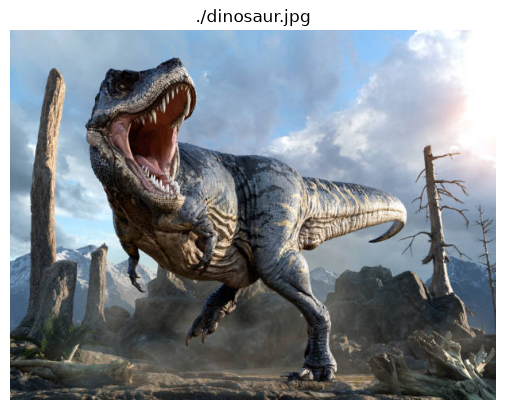

The best prediction:

'./dinosaur.jpg': 36.530784606933594% is a 'triceratops'

Top 5 prediction:

36.530784606933594% is a 'triceratops'
13.080013275146484% is a 'sturgeon'
11.30889892578125% is a 'common iguana, iguana, Iguana iguana'
5.649751663208008% is a 'rock python, rock snake, Python sebae'
3.6476004123687744% is a 'leatherback turtle, leatherback, leathery turtle, Dermochelys coriacea'


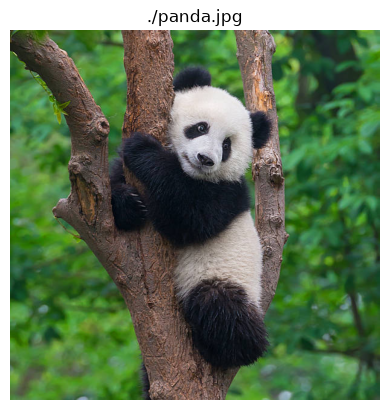

The best prediction:

'./panda.jpg': 99.97216033935547% is a 'giant panda, panda, panda bear, coon bear, Ailuropoda melanoleuca'

Top 5 prediction:

99.97216033935547% is a 'giant panda, panda, panda bear, coon bear, Ailuropoda melanoleuca'
0.020116886124014854% is a 'indri, indris, Indri indri, Indri brevicaudatus'
0.003965649288147688% is a 'gibbon, Hylobates lar'
0.001352163264527917% is a 'lesser panda, red panda, panda, bear cat, cat bear, Ailurus fulgens'
0.0006775516667403281% is a 'titi, titi monkey'


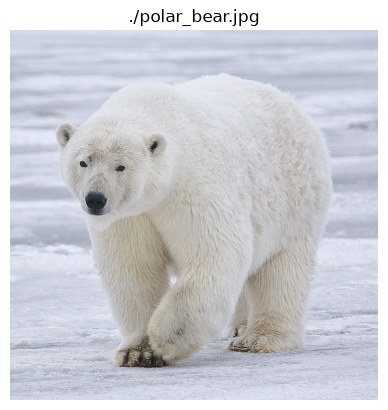

The best prediction:

'./polar_bear.jpg': 99.87646484375% is a 'ice bear, polar bear, Ursus Maritimus, Thalarctos maritimus'

Top 5 prediction:

99.87646484375% is a 'ice bear, polar bear, Ursus Maritimus, Thalarctos maritimus'
0.10136964172124863% is a 'white wolf, Arctic wolf, Canis lupus tundrarum'
0.019349833950400352% is a 'Arctic fox, white fox, Alopex lagopus'
0.002569720847532153% is a 'Samoyed, Samoyede'
0.0001575924688950181% is a 'kuvasz'


In [4]:
def classify(filename):
    input_image = Image.open(filename).convert('RGB')
    plt.figure()
    plt.imshow(input_image)
    plt.axis('off')
    plt.title(filename)
    plt.show()

    input_batch = preprocess(input_image).unsqueeze(0)
    if torch.cuda.is_available():
        input_batch = input_batch.to('cuda')

    with torch.no_grad():
        output = model(input_batch)
    percentage = torch.nn.functional.softmax(output, dim=1)[0] * 100

    print('The best prediction:\n')
    _, index = torch.max(output, 1)
    classname = key_to_classname[class_id_to_key[index[0]]]
    probability = percentage[index[0]].item()
    print("'{}': {}% is a '{}'".format(filename, probability, classname))

    print('\nTop 5 prediction:\n')
    _, indices = torch.sort(output, descending=True)
    for idx in indices[0][:5]:
        print("{}% is a '{}'".format(percentage[idx].item(), key_to_classname[class_id_to_key[idx]]))

for name in ['black_bear', 'brown_bear', 'cat', 'dinosaur', 'panda', 'polar_bear']:
    classify('./{}.jpg'.format(name))

Read imagenet_classes.txt file, and report how many classes are for classification.

In [5]:
with open('./imagenet_classes.txt', 'r') as f:
    classes = [line.strip() for line in f if line.strip()]
print('Number of classes for classification:', len(classes))

Number of classes for classification: 1000


Read the code, and report what is the input image size and how many layers of operations in AlexNet

In [6]:
print('Input image size: 3 x 224 x 224')

layers = list(model.features) + [model.avgpool] + list(model.classifier)
print('Total layers of operations:', len(layers))
print('features  :', len(model.features))
print('avgpool   : 1')
print('classifier:', len(model.classifier), end='\n\n')
print('Conv layers  :', sum(isinstance(l, torch.nn.Conv2d) for l in layers))
print('Linear layers:', sum(isinstance(l, torch.nn.Linear) for l in layers))
print('Weighted layers (conv + linear):', sum(isinstance(l, (torch.nn.Conv2d, torch.nn.Linear)) for l in layers))

Input image size: 3 x 224 x 224
Total layers of operations: 21
features  : 13
avgpool   : 1
classifier: 7

Conv layers  : 5
Linear layers: 3
Weighted layers (conv + linear): 8


## Failure cases of AlexNet
Two ways to make the model fail on images it classified correctly above: (1) a geometric change (upside-down image), (2) a tiny adversarial perturbation (FGSM).

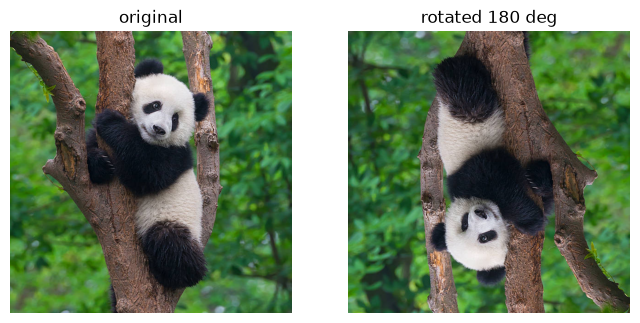

original: [('giant panda', 99.97216033935547), ('indri', 0.020116886124014854), ('gibbon', 0.003965649288147688)]


rotated : [('indri', 46.21894454956055), ('giant panda', 40.578407287597656), ('gibbon', 3.6303744316101074)]


In [7]:
def predict(img_or_tensor, topk=3):
    x = img_or_tensor if torch.is_tensor(img_or_tensor) else preprocess(img_or_tensor).unsqueeze(0)
    if torch.cuda.is_available():
        x = x.to('cuda')
    with torch.no_grad():
        p = torch.nn.functional.softmax(model(x), dim=1)[0] * 100
    top = torch.topk(p, topk)
    return [(key_to_classname[class_id_to_key[i]].split(',')[0], v.item()) for v, i in zip(top.values, top.indices)]

# Failure 1: panda turned upside down
panda = Image.open('./panda.jpg').convert('RGB')
flipped = panda.rotate(180)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for a, im, t in zip(ax, [panda, flipped], ['original', 'rotated 180 deg']):
    a.imshow(im); a.axis('off'); a.set_title(t)
plt.show()
print('original:', predict(panda))
print('rotated :', predict(flipped))

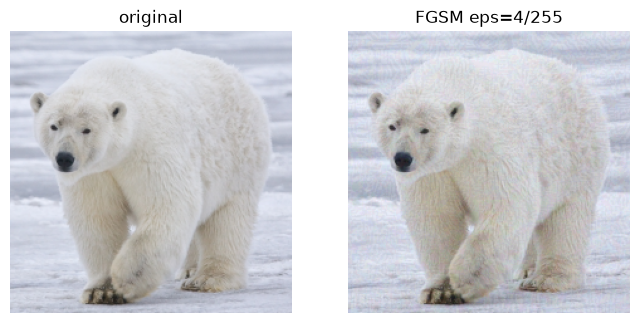

original   : [('ice bear', 99.87646484375), ('white wolf', 0.10136964172124863), ('Arctic fox', 0.019349833950400352)]
adversarial: [('white wolf', 98.43985748291016), ('Arctic fox', 0.9649783372879028), ('Samoyed', 0.3296130299568176)]


In [8]:
# Failure 2: FGSM adversarial noise on the polar bear (imperceptible perturbation)
img = Image.open('./polar_bear.jpg').convert('RGB')
x = preprocess(img).unsqueeze(0)
dev = 'cuda' if torch.cuda.is_available() else 'cpu'
x = x.to(dev).requires_grad_(True)
out = model(x)
label = out.argmax(1)
torch.nn.functional.cross_entropy(out, label).backward()

mean = torch.tensor([0.485, 0.456, 0.406], device=dev).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=dev).view(1, 3, 1, 1)
eps = 4 / 255  # max change per pixel, in [0,1] pixel units
x_adv = (x.detach() * std + mean + eps * x.grad.sign() * std.new_tensor(1)).clamp(0, 1)
x_adv = (x_adv - mean) / std

def show(t, ax, title):
    ax.imshow((t.detach() * std + mean).clamp(0, 1)[0].permute(1, 2, 0).cpu()); ax.axis('off'); ax.set_title(title)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
show(x, ax[0], 'original'); show(x_adv, ax[1], 'FGSM eps=4/255')
plt.show()
print('original   :', predict(x.detach()))
print('adversarial:', predict(x_adv))

## Image with cats and dogs
classify the multi-object image `living-with-cats-dogs-689902.jpg`.

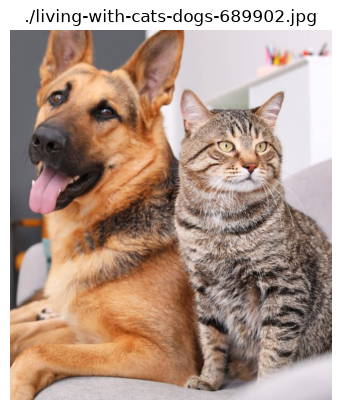

The best prediction:

'./living-with-cats-dogs-689902.jpg': 26.30905532836914% is a 'tiger cat'

Top 5 prediction:

26.30905532836914% is a 'tiger cat'
13.073854446411133% is a 'tabby, tabby cat'
12.566227912902832% is a 'German shepherd, German shepherd dog, German police dog, alsatian'
12.481060981750488% is a 'Egyptian cat'
8.625587463378906% is a 'tiger, Panthera tigris'


In [9]:
classify('./living-with-cats-dogs-689902.jpg')